In [1]:
from __future__ import annotations

from pathlib import Path

from helpers._helpers import (
    build_ablation_panels_paths,
    build_panels_paths_generic,
    build_power_panels_paths_generic,
    load_panels_from_paths,
    load_power_run_npz,
)
import matplotlib.pyplot as plt

from olbootstrap.plotting._plotting import BootstrapPlotter
from olbootstrap.study._study import UniformCoverageStudy

/opt/anaconda3/envs/bootstrap/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


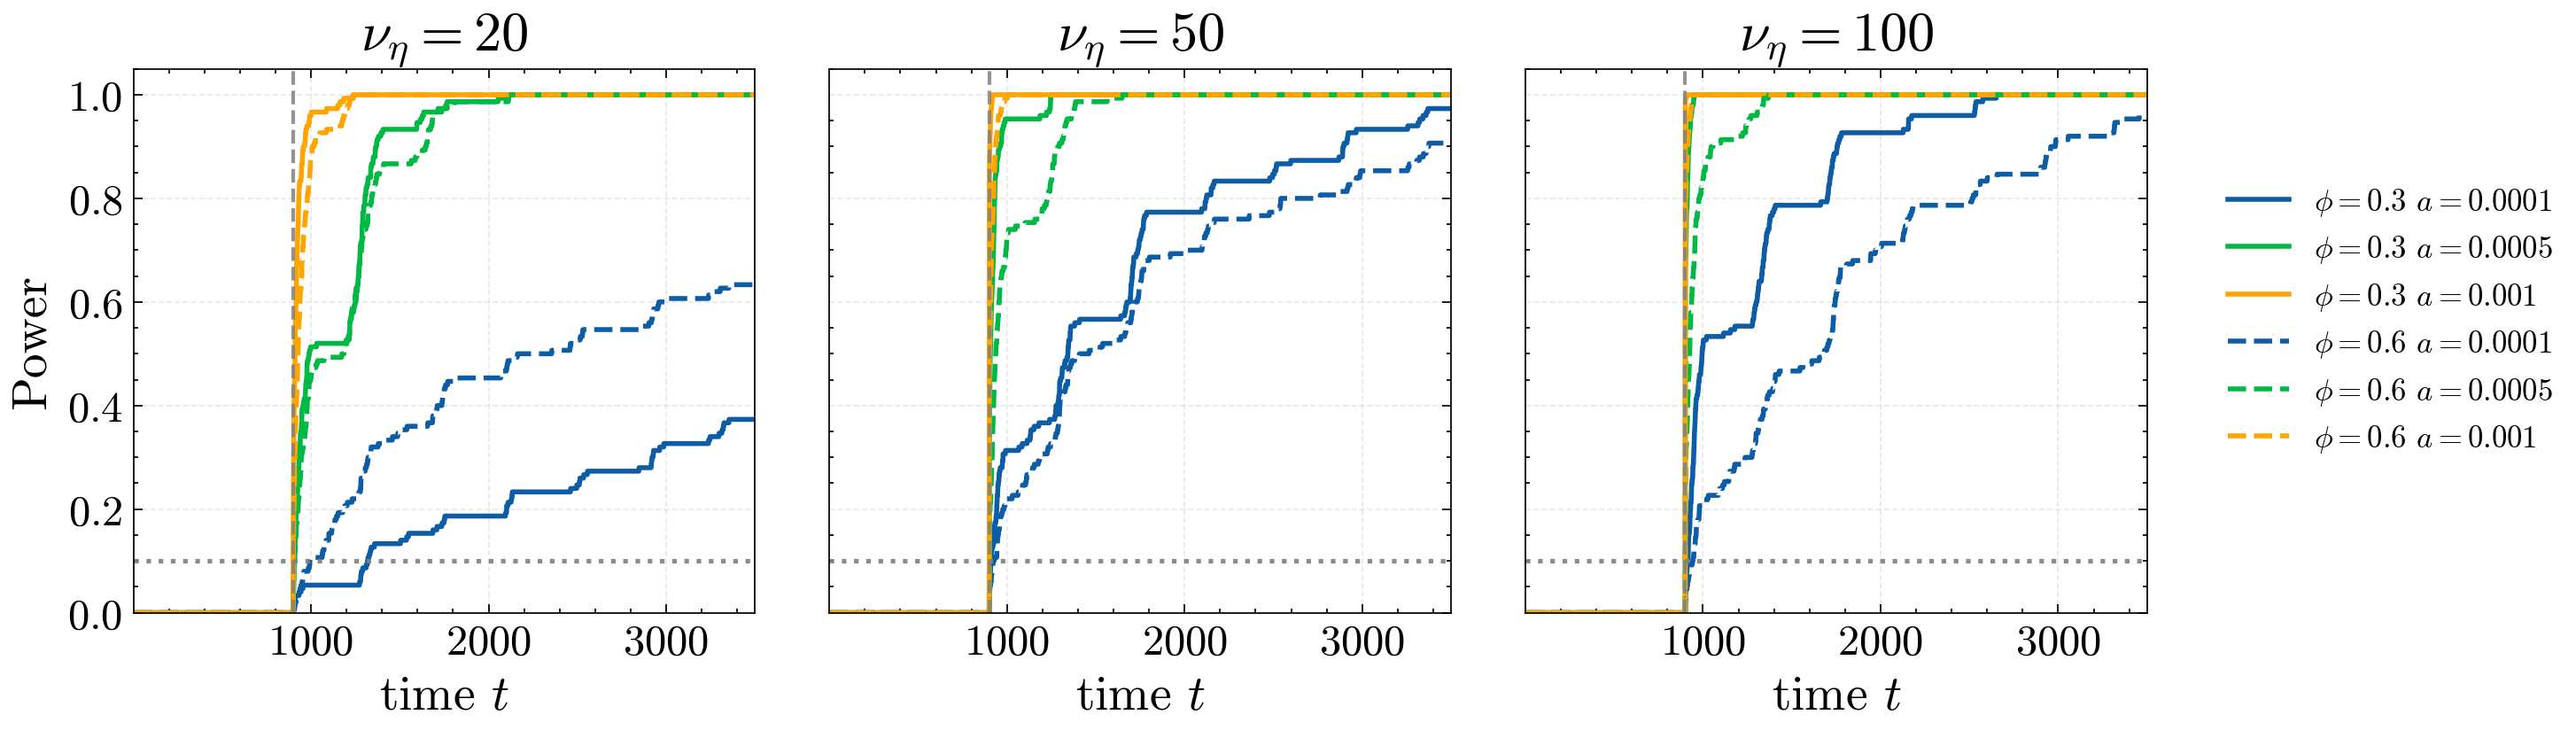

In [5]:
root = Path("..") / "experiments" / "power_ewma_alpha-0p1"

panel_specs = {
    r"$\nu_\eta=20$": {"eta": str(2 / 20)},
    r"$\nu_\eta=50$": {"eta": str(2 / 50)},
    r"$\nu_\eta=100$": {"eta": str(2 / 100)},
}

phis = {"0.3": r"$\phi=0.3$", "0.6": r"$\phi=0.6$"}
trend_slopes = {
    "0.0001": r"$a=0.0001$",
    "0.0005": r"$a=0.0005$",
    "0.001": r"$a=0.001$",
}

methods = [("ARmmult", "student")]
method_display = {"ARmmult": ""}  # keep labels clean

panels_paths_power = build_power_panels_paths_generic(
    root=root,
    panel_specs=panel_specs,
    phis=phis,
    trend_slopes=trend_slopes,
    methods=methods,
    method_display=method_display,
    smooth="ewma",
    alpha="0.1",
    bi=500,
    vw=400,
    n=3500,
    nseries=150,
    B=400,
    nosmooth_var=True,
    seaA="0.4",
    seaP="400",
)

panels_power = load_panels_from_paths(panels_paths_power, loader=load_power_run_npz)
panels_power = {
    title: {"runs": entry["sweeps"], "labels": entry["labels"]}
    for title, entry in panels_power.items()
}

outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)
save_path = outdir / "power_overlay_grid_ewma_alpha01.pdf"

plotter = BootstrapPlotter(style="science", figsize=(12, 3), dpi=250)

fig, axes, _ = plotter.plot_power_overlay_grid(
    panels_power,
    order=[r"$\nu_\eta=20$", r"$\nu_\eta=50$", r"$\nu_\eta=100$"],
    layout=(1, 3),
    metric="power",
    show_target=True,
    show_burn=True,
    common_legend=True,
    legend_in_panel=False,
    legend_outside_right=True,
    legend_panel_index=-1,  # put legend in last panel (right-most)
    color_by_group=True,
    dashed_phi=("0.6",),
    legend_fontsize=10,
    tick_labelsize=14,
    axis_labelsize=16,
    title_size=18,
    line_width=1.6,
    label_left_only=True,
    save_path=save_path,
    show=True,
    single_ylabel="Power",
    hspace=0.25,
    wspace=0.12,
)

In [15]:
base = Path("..") / "experiments"

root = base / "smooth-ewma_alpha-0p1"
panel_specs_main = {
    "Stationary": {"shock": "__shock-type-none_p-0_scale-1"},
    "Trend + seasonality": {
        "shock": "__shock-type-none_p-0_scale-1",
        "tail": "__trend-0p001__seaA-0p4__seaP-400",
    },
    "Trend + shocks": {
        "shock": "__shock-type-permanent_p-0p005_scale-2",
        "tail": "__trend-0p001",
    },
}
phis = {"0.3": r"$\phi=0.3$", "0.6": r"$\phi=0.6$"}
# phis = {"0.3": r"$\phi=0.3$"}
methods = [
    ("ARmmult", "student"),
    ("ARmrho0", "gauss"),
    ("GaussMix", "student"),
    ("Block", "student"),
]
method_display = {
    "ARmmult": "ours",
    "GaussMix": "WS",
    "ARmrho0": "iid",
    "Block": "block",
}
# method_display = {"ARmmult": "ours", "Block": "block"}

panels_paths = build_panels_paths_generic(
    root=root,
    phis=phis,
    methods=methods,
    method_display=method_display,
    panel_specs=panel_specs_main,
    smooth="ewma",
    alpha="0.1",
    bi=500,
    vw=400,
    n=3500,
    nseries=150,
    B=400,
    nosmooth_var=True,
    sweep_prefix=False,
    include_method_token=True,
)

panels_ewma_a01 = load_panels_from_paths(
    panels_paths, loader=UniformCoverageStudy.load_sweep
)

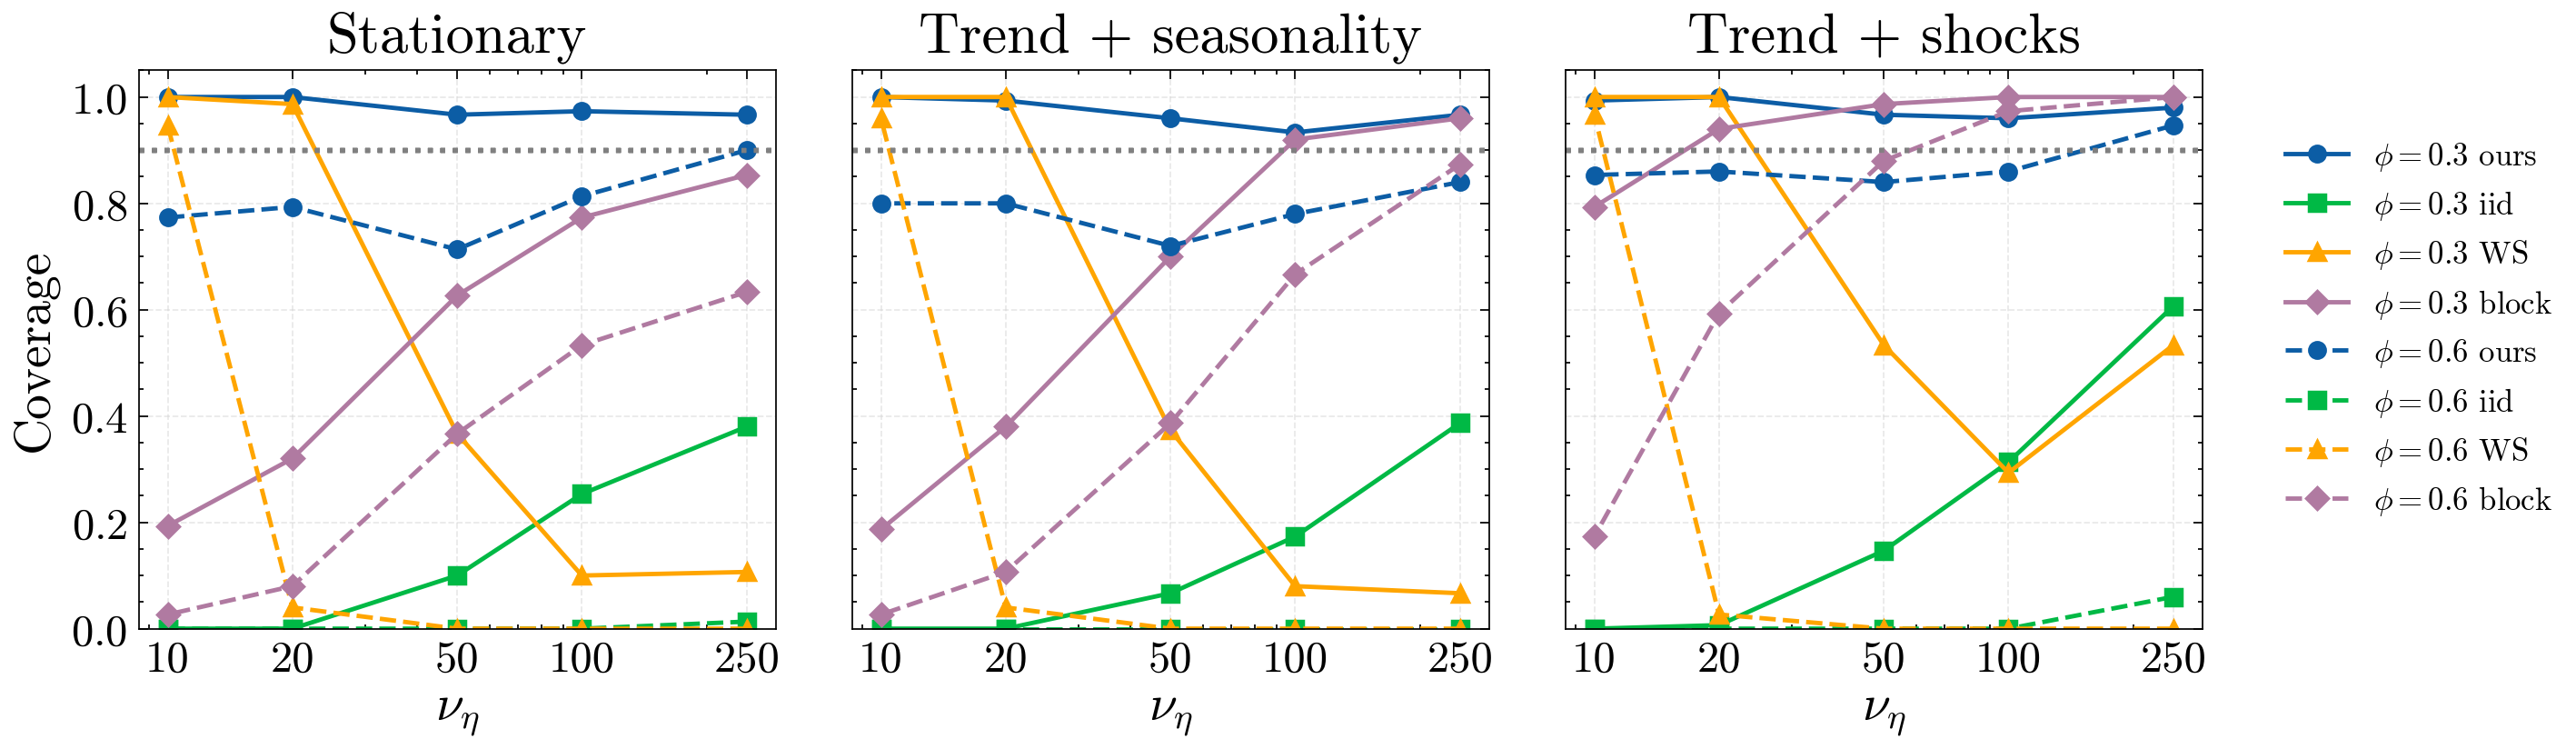

Saved to: /Users/toby/bootstrap/notebooks/figs/sweep_overlay_grid_ewma_alpha01.pdf


In [16]:
outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)
save_path = outdir / "sweep_overlay_grid_ewma_alpha01.pdf"

plotter = BootstrapPlotter(style="science", figsize=(12, 3), dpi=250)
fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels_ewma_a01,
    order=[
        "Stationary",
        "Trend + seasonality",
        "Trend + shocks",
    ],  # only plot one panel since we only have one
    layout=(1, 3),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=True,
    legend_in_panel=False,
    legend_outside_right=True,
    legend_panel_index=-1,
    legend_fontsize=10,
    tick_labelsize=14,
    axis_labelsize=16,
    title_size=18,
    marker_size=5,
    line_width=1.4,
    hspace=0.25,
    wspace=0.12,
    save_path=save_path,
    log_eta=True,
    style_by_method=True,
    method_from_label="last_token",
    method_order=["ours", "iid", "WS", "block"],
    method_colors={
        "block": "#B07AA1",
    },
    ess=True,
)

plt.show()

print("Saved to:", save_path.resolve())

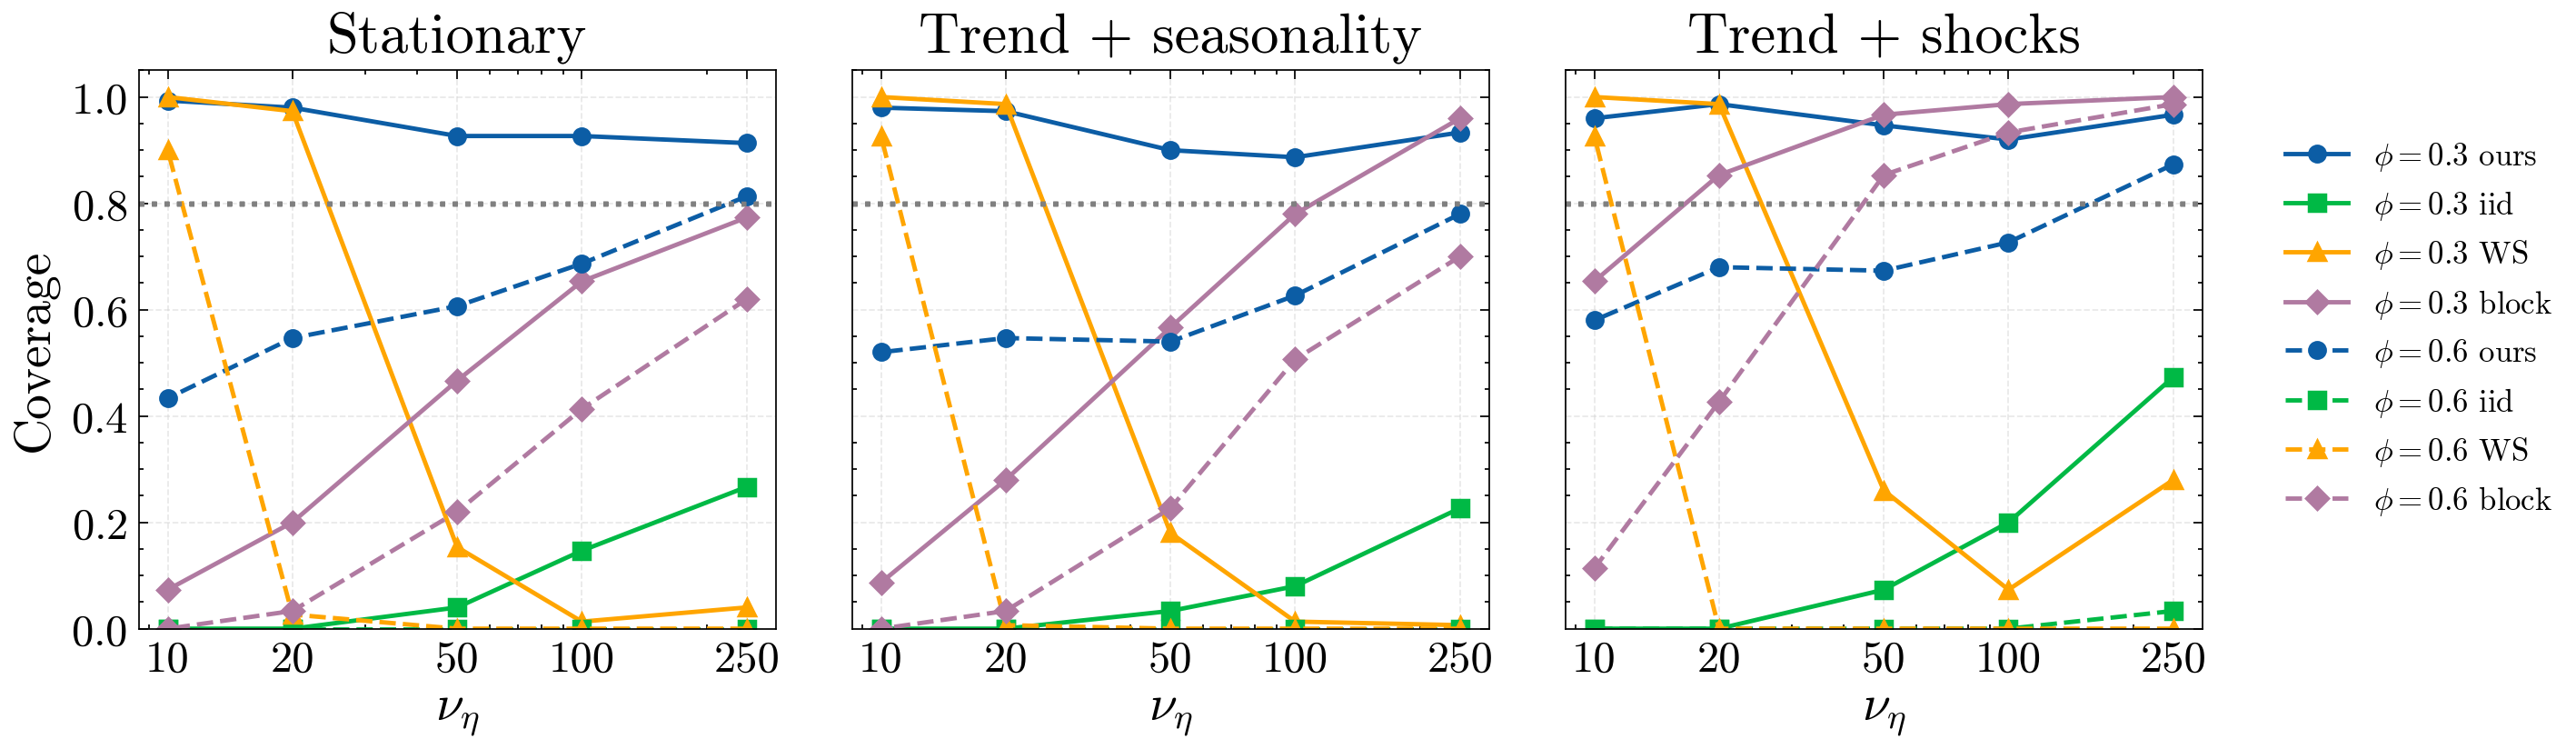

Saved to: /Users/toby/bootstrap/notebooks/figs/sweep_overlay_grid_ewma_alpha02.pdf


In [17]:
root = base / "smooth-ewma_alpha-0p2"

panels_paths_ewma_a02 = build_panels_paths_generic(
    root=root,
    phis=phis,
    methods=methods,
    method_display=method_display,
    panel_specs=panel_specs_main,
    smooth="ewma",
    alpha="0.2",
    bi=500,
    vw=400,
    n=3500,
    nseries=150,
    B=400,
    nosmooth_var=True,
    sweep_prefix=False,
    include_method_token=True,
)

panels_ewma_a02 = load_panels_from_paths(
    panels_paths_ewma_a02,
    loader=UniformCoverageStudy.load_sweep,
)

outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)
save_path = outdir / "sweep_overlay_grid_ewma_alpha02.pdf"

plotter = BootstrapPlotter(style="science", figsize=(12, 3), dpi=250)
fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels_ewma_a02,
    order=["Stationary", "Trend + seasonality", "Trend + shocks"],
    layout=(1, 3),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=True,
    legend_in_panel=False,
    legend_outside_right=True,
    legend_panel_index=-1,
    legend_fontsize=10,
    tick_labelsize=14,
    axis_labelsize=16,
    title_size=18,
    marker_size=5,
    line_width=1.4,
    hspace=0.25,
    wspace=0.12,
    save_path=save_path,
    log_eta=True,
    style_by_method=True,
    method_from_label="last_token",
    method_order=["ours", "iid", "WS", "block"],
    ess=True,
)

plt.show()

print("Saved to:", save_path.resolve())

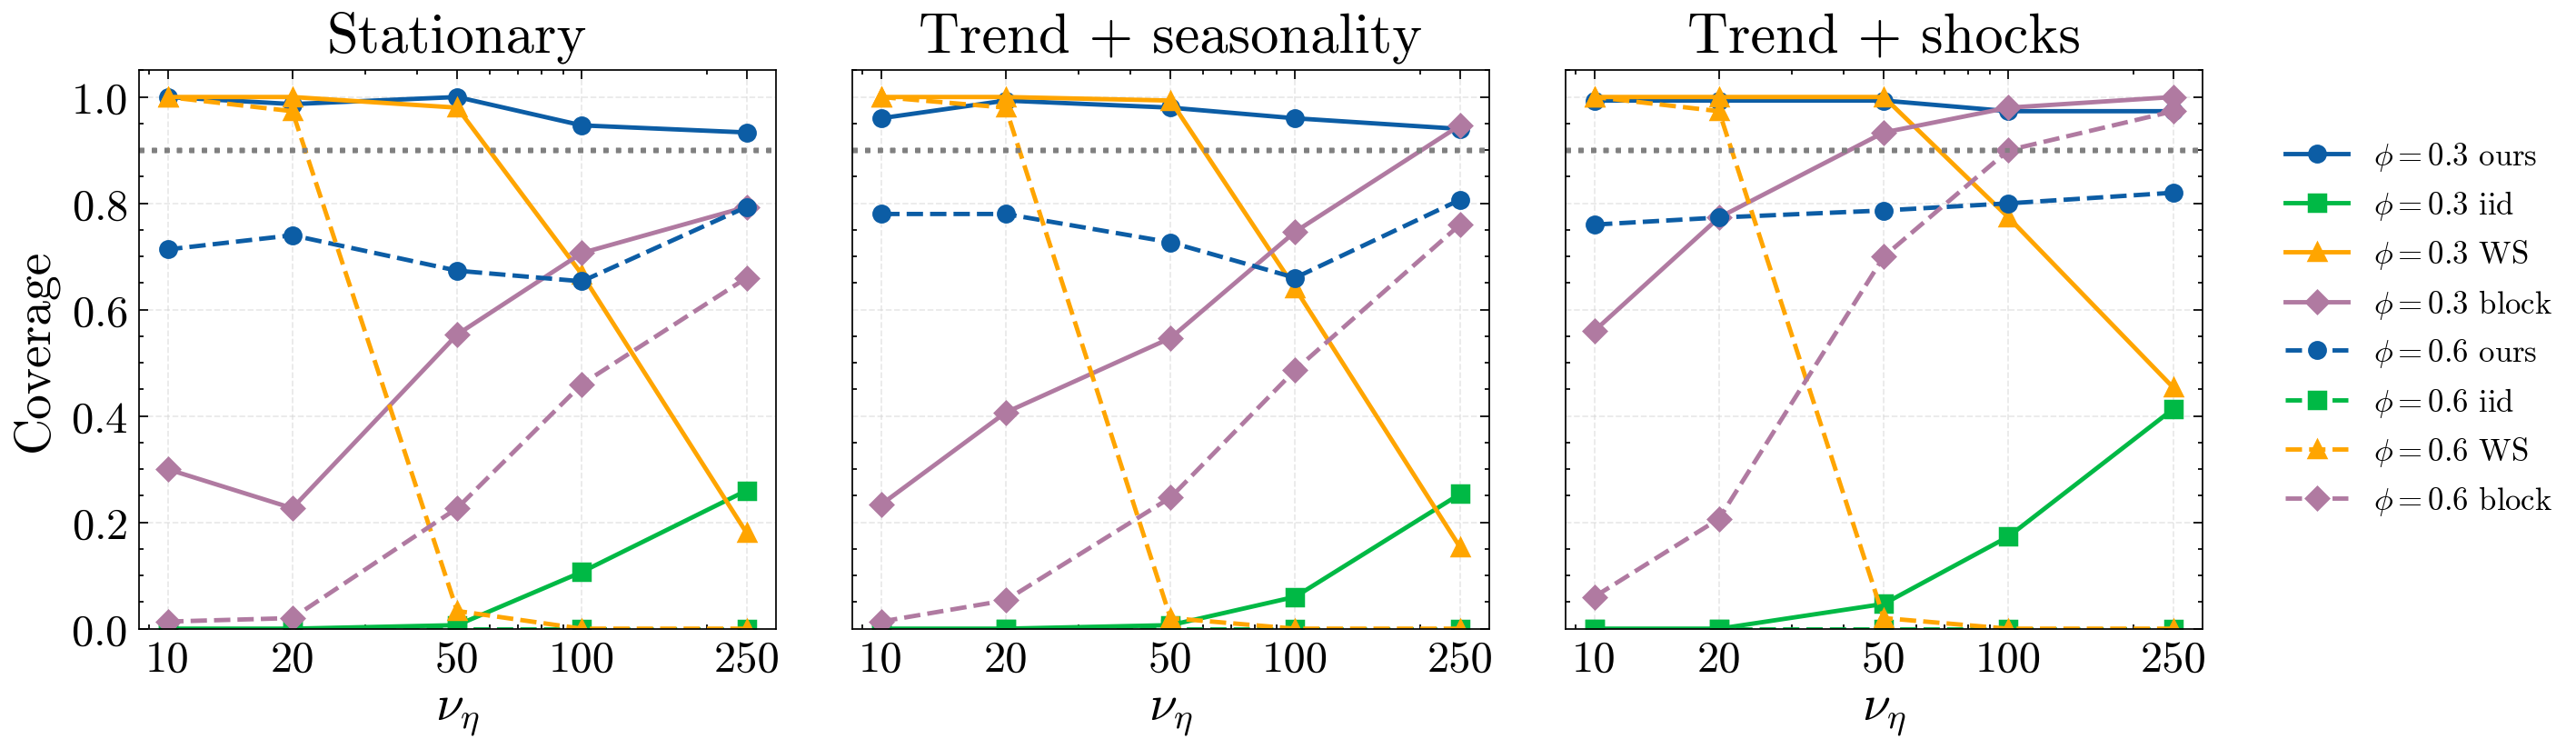

Saved to: /Users/toby/bootstrap/notebooks/figs/sweep_overlay_grid_brown_alpha01.pdf


In [18]:
root = base / "smooth-brown_alpha-0p1"

panels_paths_brown_a01 = build_panels_paths_generic(
    root=root,
    phis=phis,
    methods=methods,
    method_display=method_display,
    panel_specs=panel_specs_main,
    smooth="brown",
    alpha="0.1",
    bi=500,
    vw=400,
    n=3500,
    nseries=150,
    B=400,
    nosmooth_var=True,
    sweep_prefix=False,
    include_method_token=True,
)

panels_brown_a01 = load_panels_from_paths(
    panels_paths_brown_a01,
    loader=UniformCoverageStudy.load_sweep,
)


outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)
save_path = outdir / "sweep_overlay_grid_brown_alpha01.pdf"

plotter = BootstrapPlotter(style="science", figsize=(12, 3), dpi=250)
fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels_brown_a01,
    order=["Stationary", "Trend + seasonality", "Trend + shocks"],
    layout=(1, 3),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=True,
    legend_in_panel=False,
    legend_outside_right=True,
    legend_panel_index=-1,
    legend_fontsize=10,
    tick_labelsize=14,
    axis_labelsize=16,
    title_size=18,
    marker_size=5,
    line_width=1.4,
    hspace=0.25,
    wspace=0.12,
    save_path=save_path,
    log_eta=True,
    style_by_method=True,
    method_from_label="last_token",
    method_order=["ours", "iid", "WS", "block"],
    ess=True,
)

plt.show()

print("Saved to:", save_path.resolve())

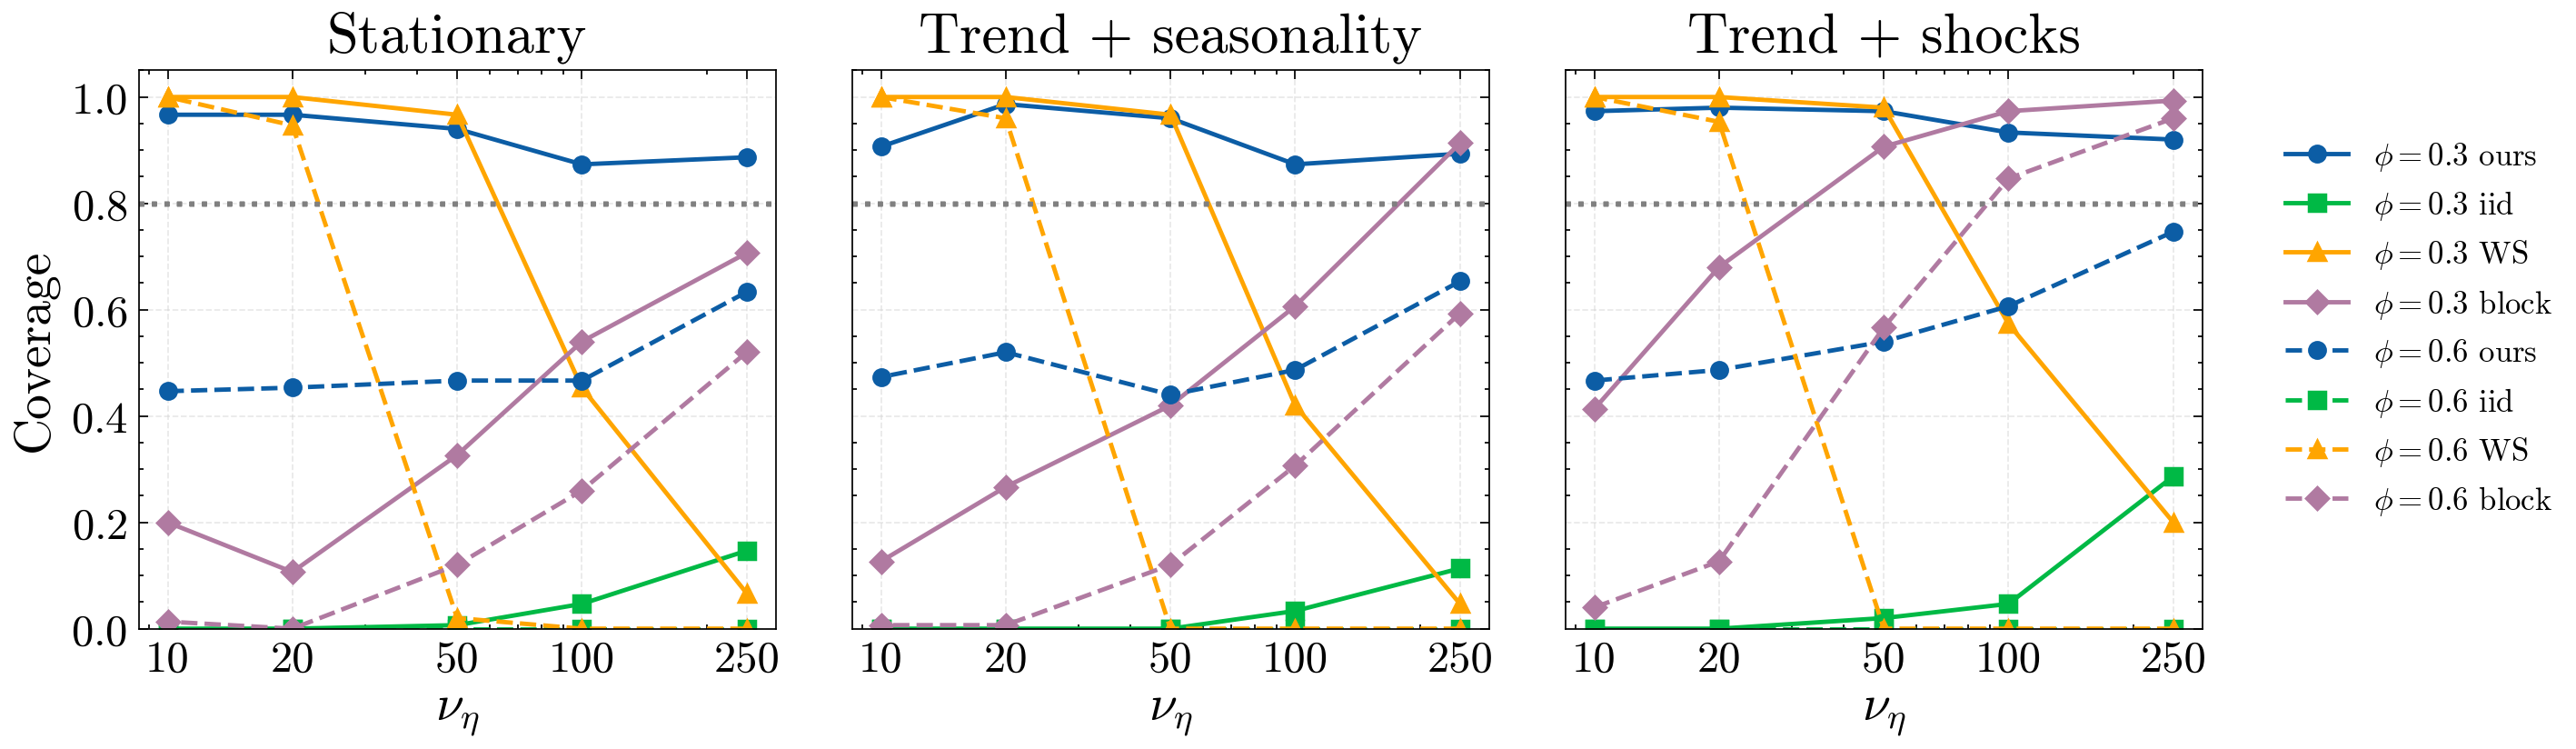

Saved to: /Users/toby/bootstrap/notebooks/figs/sweep_overlay_grid_brown_alpha02.pdf


In [21]:
root = base / "smooth-brown_alpha-0p2"

panels_paths_brown_a02 = build_panels_paths_generic(
    root=root,
    phis=phis,
    methods=methods,
    method_display=method_display,
    panel_specs=panel_specs_main,
    smooth="brown",
    alpha="0.2",
    bi=500,
    vw=400,
    n=3500,
    nseries=150,
    B=400,
    nosmooth_var=True,
    sweep_prefix=False,
    include_method_token=True,
)

panels_brown_a02 = load_panels_from_paths(
    panels_paths_brown_a02,
    loader=UniformCoverageStudy.load_sweep,
)


outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)
save_path = outdir / "sweep_overlay_grid_brown_alpha02.pdf"

plotter = BootstrapPlotter(style="science", figsize=(12, 3), dpi=250)
fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels_brown_a02,
    order=["Stationary", "Trend + seasonality", "Trend + shocks"],
    layout=(1, 3),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=True,
    legend_in_panel=False,
    legend_outside_right=True,
    legend_panel_index=-1,
    legend_fontsize=10,
    tick_labelsize=14,
    axis_labelsize=16,
    title_size=18,
    marker_size=5,
    line_width=1.4,
    hspace=0.25,
    wspace=0.12,
    save_path=save_path,
    log_eta=True,
    style_by_method=True,
    method_from_label="last_token",
    method_order=["ours", "iid", "WS", "block"],
    ess=True,
)

plt.show()

print("Saved to:", save_path.resolve())

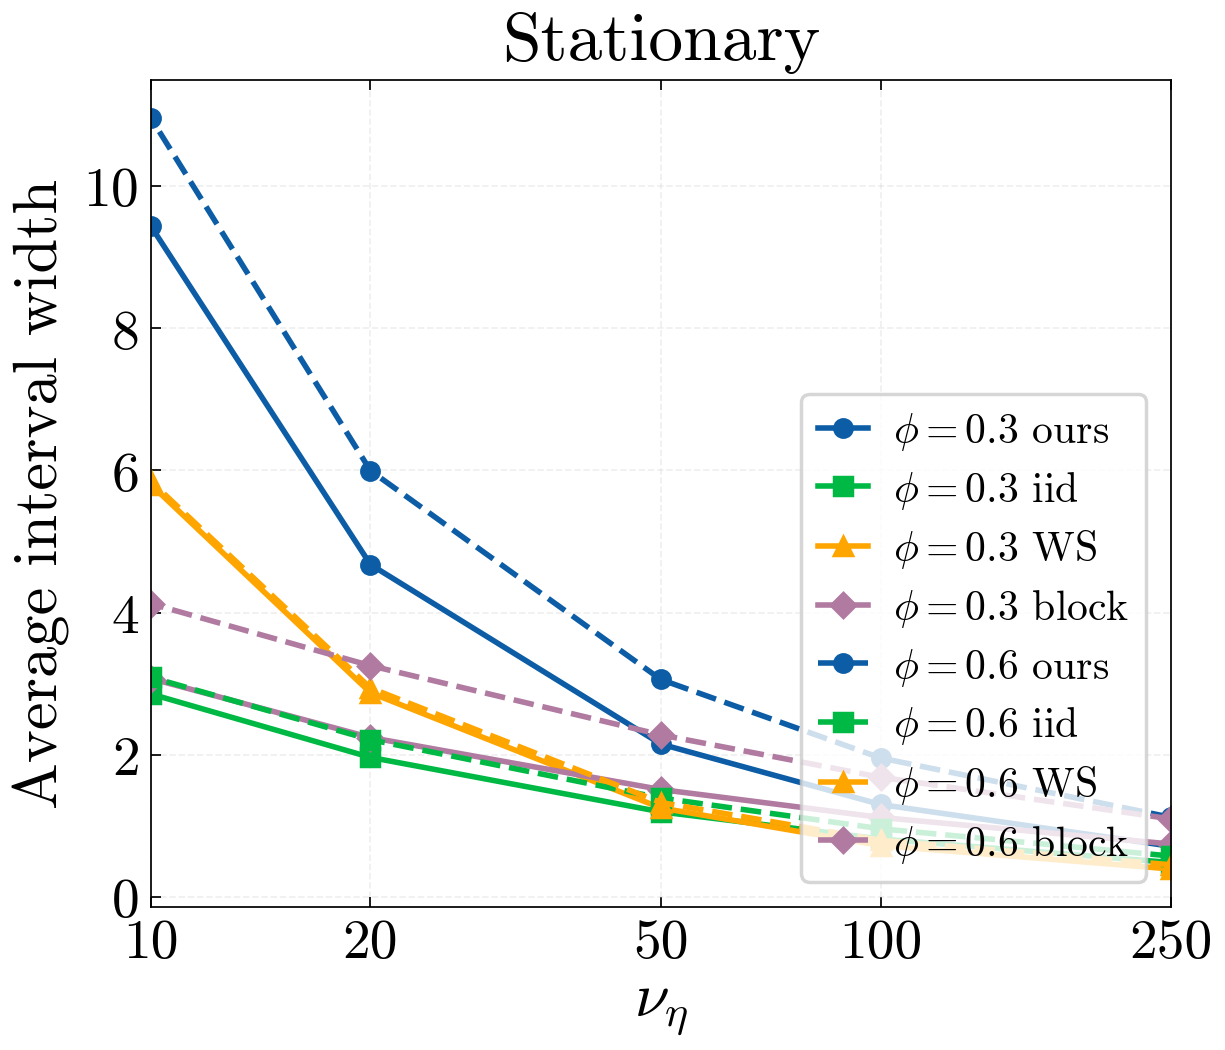

In [22]:
plotter = BootstrapPlotter(style="science", figsize=(8, 4), dpi=250)

stationary_panels = {"Stationary": panels_ewma_a01["Stationary"]}

fig_stat, ax_stat = plotter.plot_avg_uniform_width_grid(
    stationary_panels,
    order=["Stationary"],
    layout=(1, 1),
    figsize=(5, 4),
    marker_size=5,
    line_width=1.6,
    hspace=0.25,
    legend_fontsize=12,
    tick_labelsize=16,
    axis_labelsize=18,
    title_size=20,
    save_path=Path("figs/avg_uniform_widths_stationary.pdf"),
    show=True,
    legend_inside_bottom_right=True,
    legend_loc="inplot-br",
    log_eta=True,
    style_by_method=True,
    method_from_label="last_token",
    method_order=["ours", "iid", "WS", "block"],
    ess=True,
)

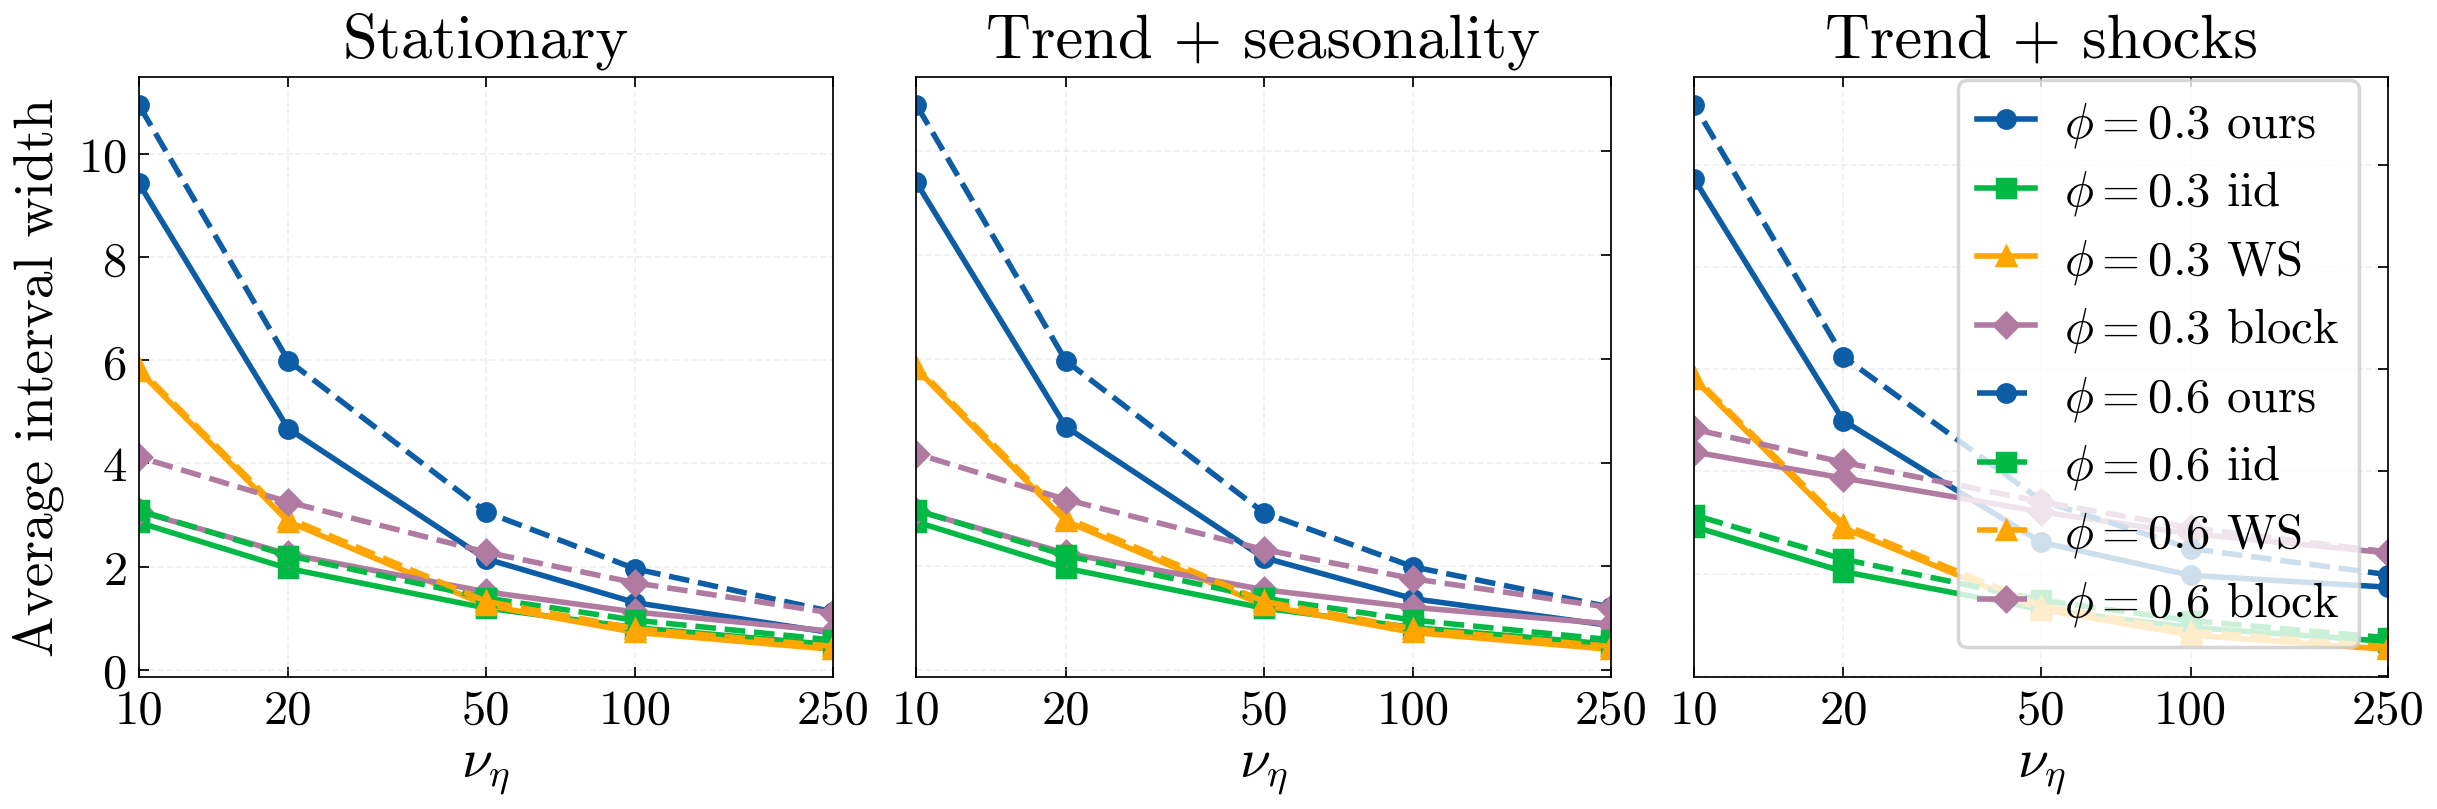

In [23]:
other_order = ["Stationary", "Trend + seasonality", "Trend + shocks"]
other_panels = {k: panels_ewma_a01[k] for k in other_order}

fig_trends, axes_trends = plotter.plot_avg_uniform_width_grid(
    other_panels,
    order=other_order,
    dpi=250,
    layout=(1, 3),
    figsize=(10, 3),
    marker_size=5,
    line_width=1.6,
    hspace=0.25,
    legend_fontsize=14,
    axis_labelsize=16,
    tick_labelsize=14,
    title_size=18,
    save_path=Path("figs/avg_uniform_widths_trends.pdf"),
    show=True,
    legend_inside_bottom_right=True,
    legend_loc="inplot-br",
    log_eta=True,
    log_y=False,
    style_by_method=True,
    method_from_label="last_token",
    method_order=["ours", "iid", "WS", "block"],
    ess=True,
)

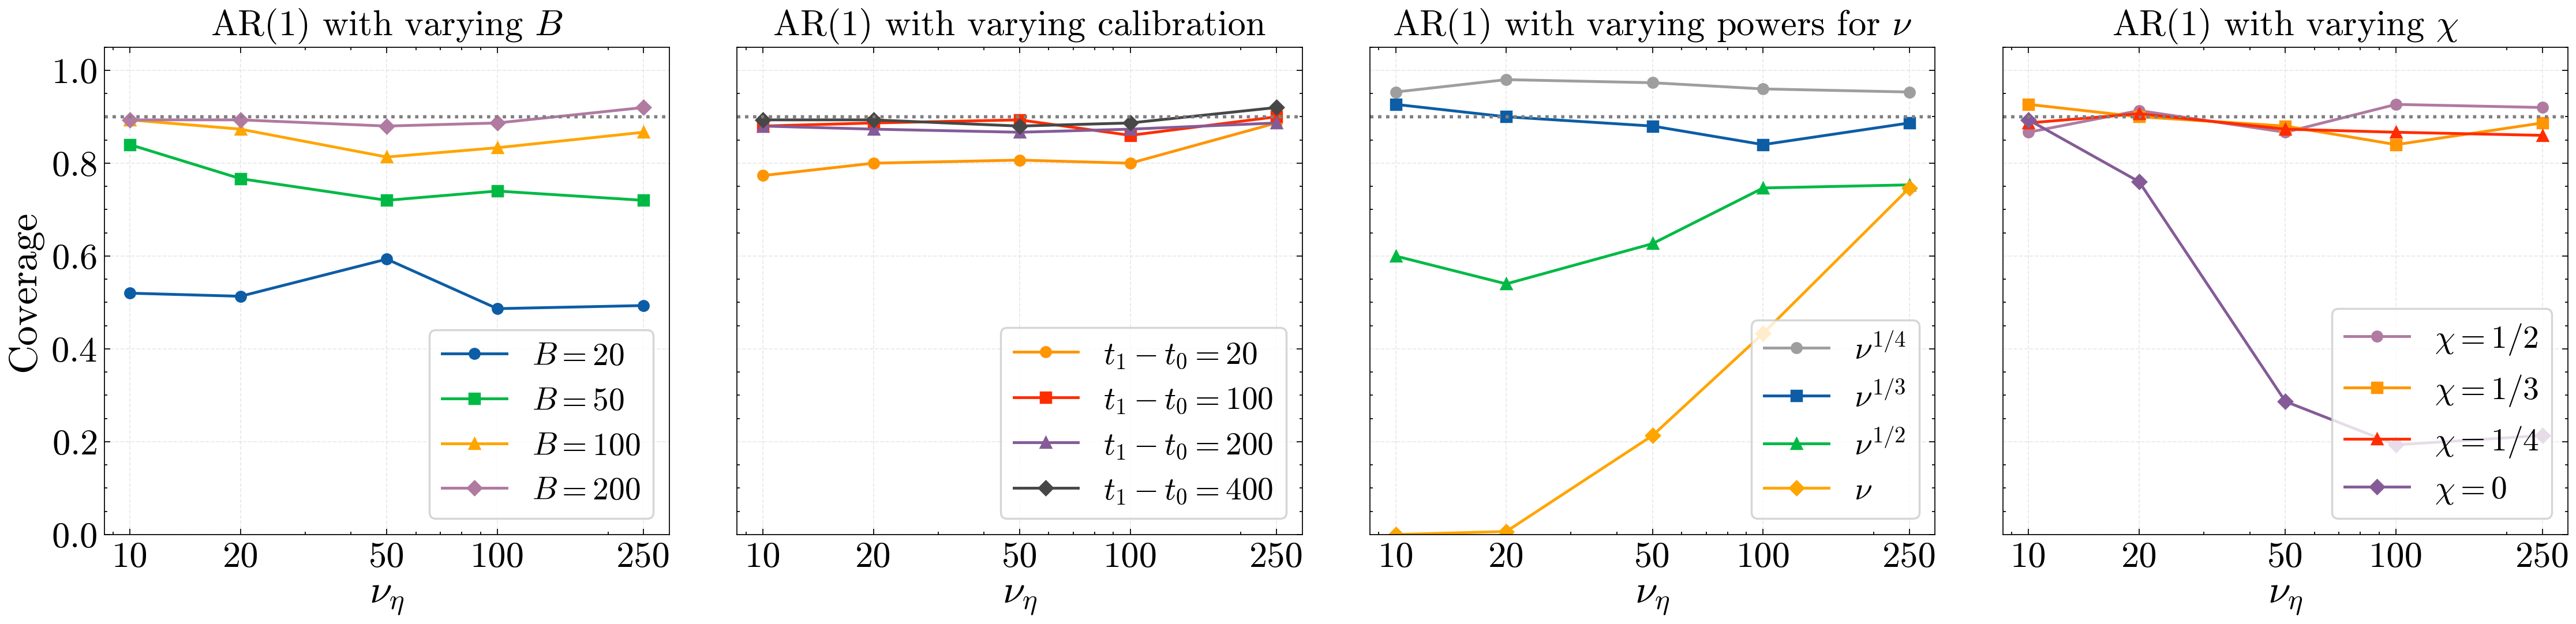

Saved to: /Users/toby/bootstrap/notebooks/figs/sweep_overlay_grid_B_m_nu_rho.pdf


In [2]:
base = Path("..") / "experiments"

panels_paths = build_ablation_panels_paths(base=base)

panels = load_panels_from_paths(panels_paths, loader=UniformCoverageStudy.load_sweep)

outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)
save_path = outdir / "sweep_overlay_grid_B_m_nu_rho.pdf"

plotter = BootstrapPlotter(style="science", figsize=(18, 4), dpi=250)
fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels,
    order=[
        "AR(1) with varying $B$",
        "AR(1) with varying calibration",
        r"AR(1) with varying powers for $\nu$",
        r"AR(1) with varying $\chi$",
    ],
    layout=(1, 4),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=False,
    legend_in_panel=True,
    legend_panel_index=-1,
    legend_fontsize=16,
    tick_labelsize=18,
    axis_labelsize=20,
    title_size=18,
    marker_size=5,
    line_width=1.4,
    hspace=0.25,
    wspace=0.12,
    save_path=str(save_path),
    log_eta=True,
    color_by_group=True,
    ess=True,
)

print("Saved to:", save_path.resolve())

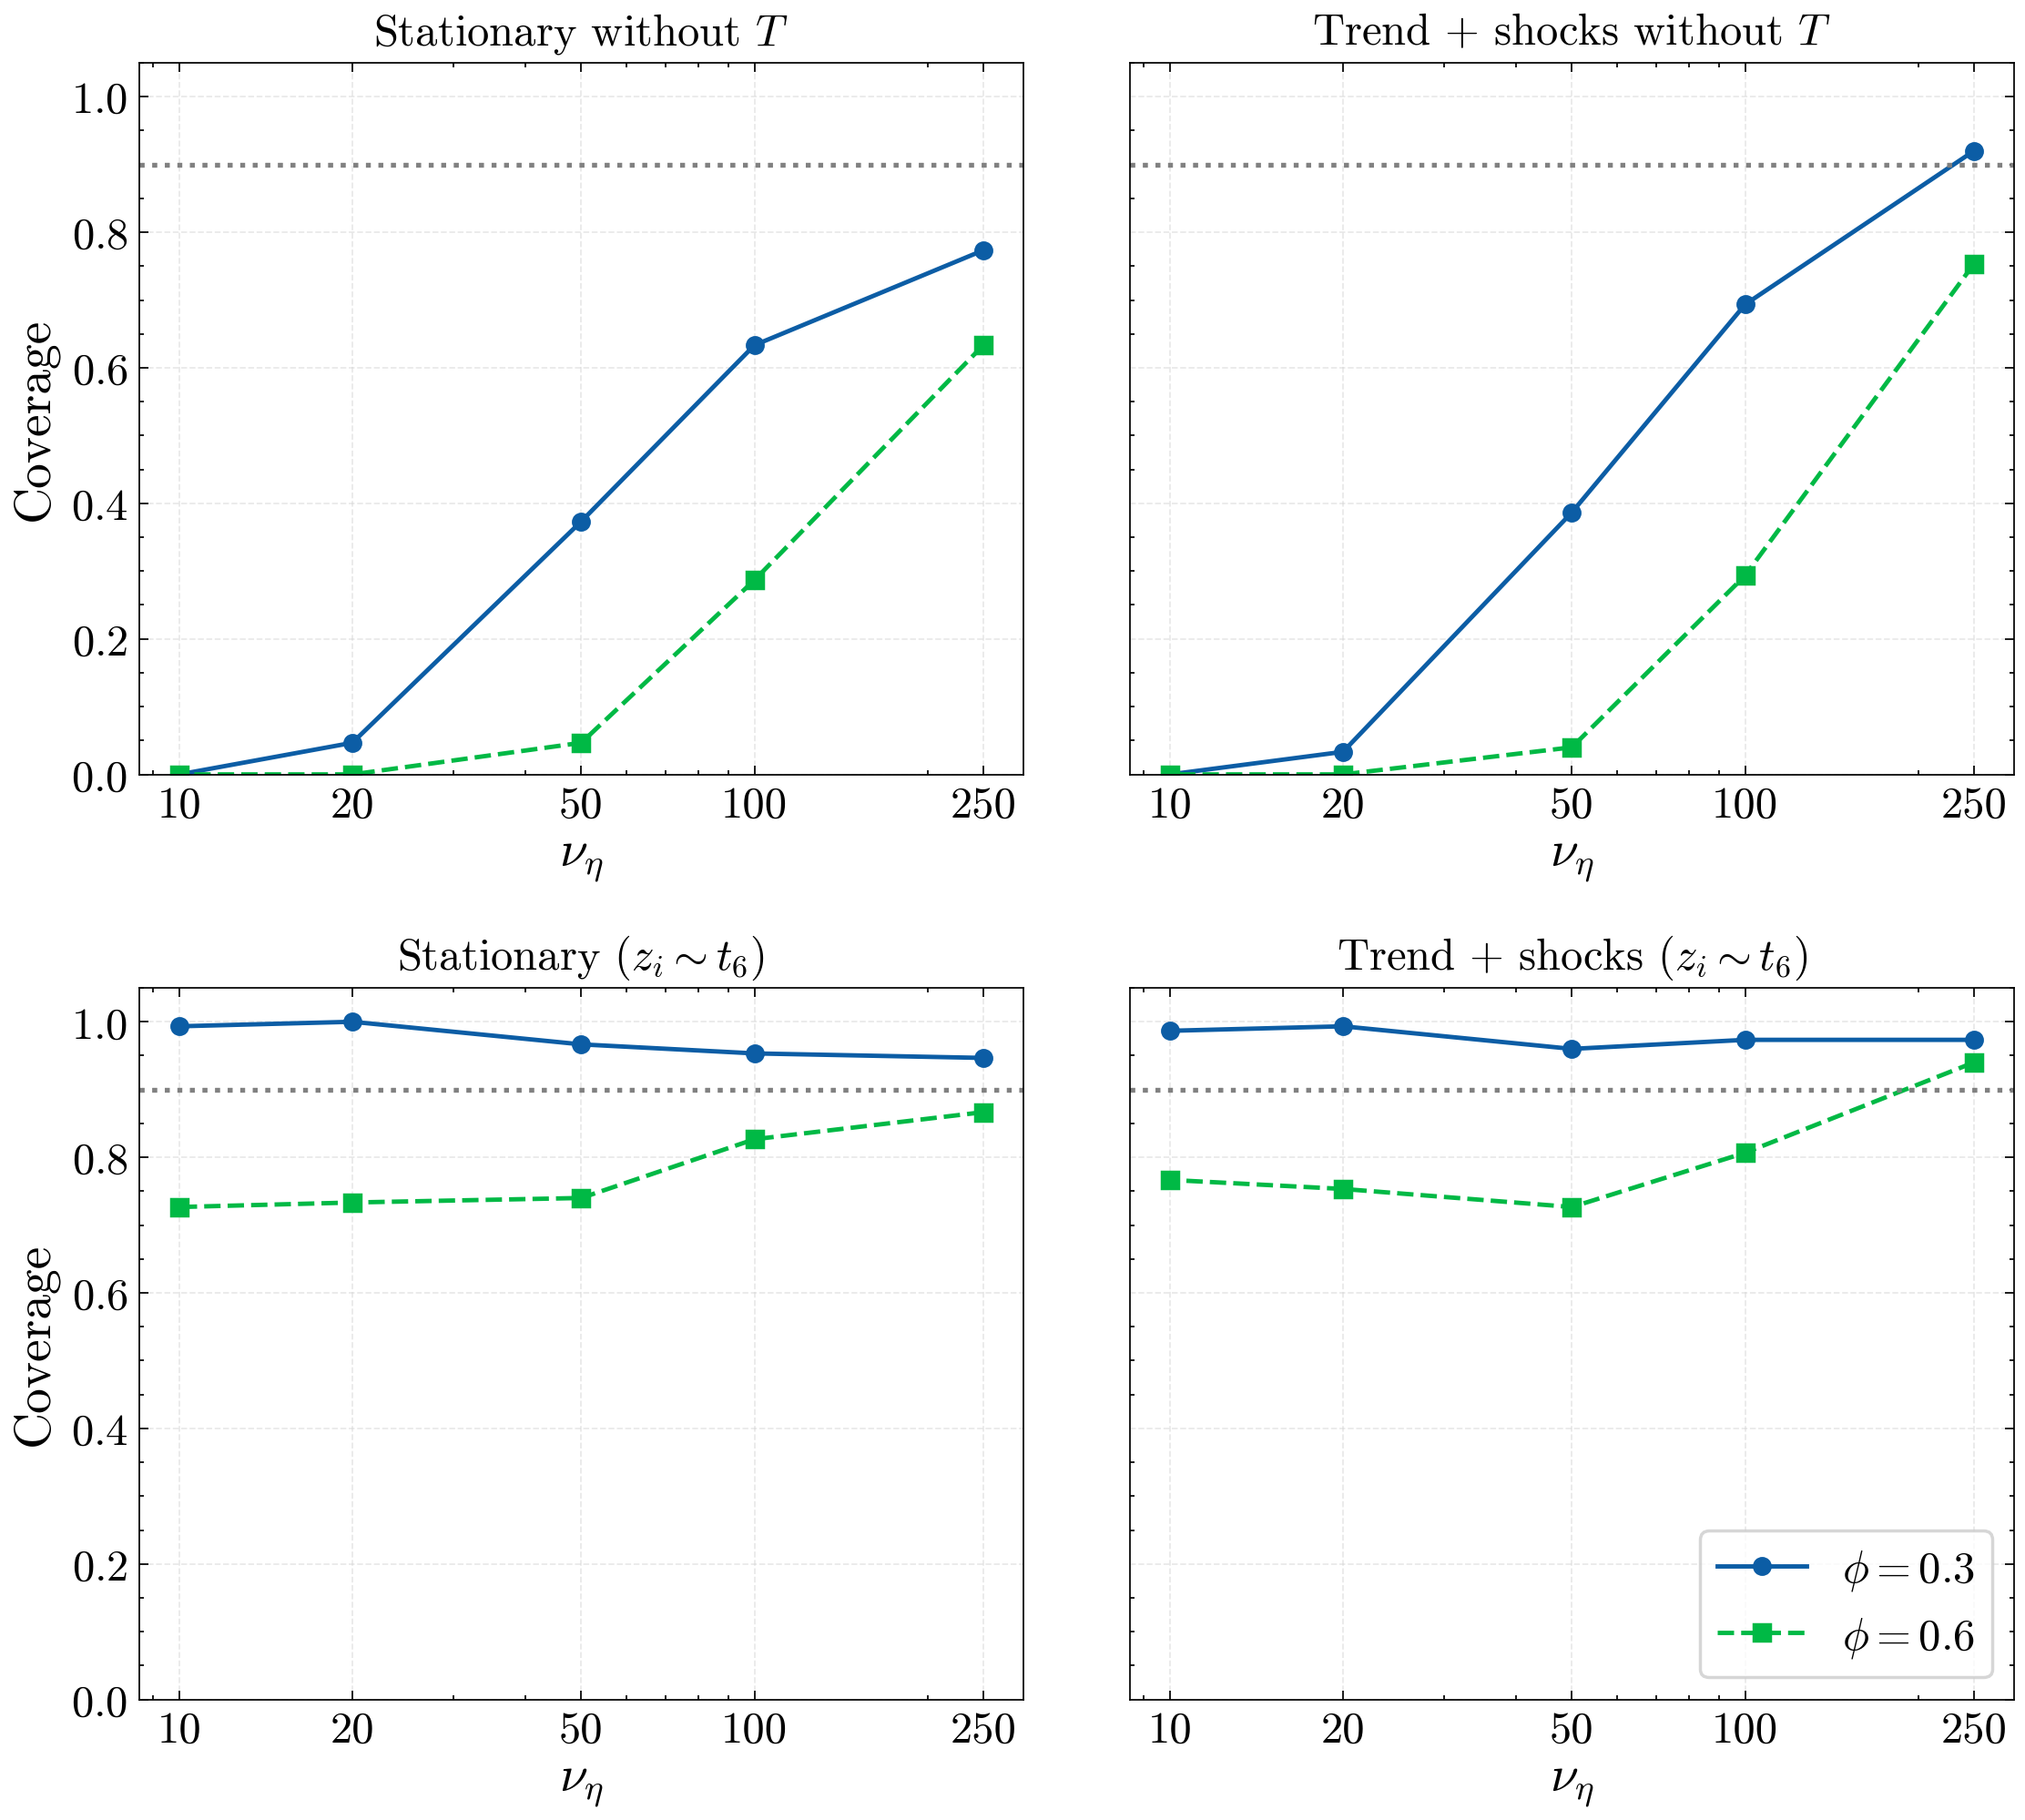

Saved to: /Users/toby/bootstrap/notebooks/figs/ablation_T_vs_t6_2x2.pdf


In [3]:
phis = {"0.3": r"$\phi=0.3$", "0.6": r"$\phi=0.6$"}
method_display = {"ARmmult": ""}

panel_specs_tt = {
    "Stationary": {"shock": "__shock-type-none_p-0_scale-1"},
    "Trend + shocks": {
        "shock": "__shock-type-permanent_p-0p005_scale-2",
        "tail": "__trend-0p001",
    },
}

root_T = base / "smooth-ewma_alpha-0p1" / "ablations"
root_t6 = base / "smooth-ewma_alpha-0p1" / "ablations_ttails"

paths_T = build_panels_paths_generic(
    root=root_T,
    phis=phis,
    methods=[("ARmmult", "gauss")],
    method_display=method_display,
    panel_specs=panel_specs_tt,
    smooth="ewma",
    alpha="0.1",
    bi=500,
    vw=400,
    n=3500,
    nseries=150,
    B=200,
    nosmooth_var=True,
    sweep_prefix=False,
    include_method_token=True,
)

paths_t6 = build_panels_paths_generic(
    root=root_t6,
    phis=phis,
    methods=[("ARmmult", "student")],
    method_display=method_display,
    panel_specs=panel_specs_tt,
    smooth="ewma",
    alpha="0.1",
    bi=500,
    vw=400,
    n=3500,
    nseries=150,
    B=200,
    nosmooth_var=True,
    sweep_prefix=False,
    include_method_token=True,
)

panels_T = load_panels_from_paths(paths_T, loader=UniformCoverageStudy.load_sweep)
panels_t6 = load_panels_from_paths(paths_t6, loader=UniformCoverageStudy.load_sweep)

panels_2x2 = {
    r"Stationary without $T$": panels_T["Stationary"],
    r"Trend + shocks without $T$": panels_T["Trend + shocks"],
    r"Stationary ($z_i\sim t_6$)": panels_t6["Stationary"],
    r"Trend + shocks ($z_i\sim t_6$)": panels_t6["Trend + shocks"],
}


outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)
save_path = outdir / "ablation_T_vs_t6_2x2.pdf"

plotter = BootstrapPlotter(style="science", figsize=(9, 8), dpi=250)
fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels_2x2,
    order=[
        r"Stationary without $T$",
        r"Trend + shocks without $T$",
        r"Stationary ($z_i\sim t_6$)",
        r"Trend + shocks ($z_i\sim t_6$)",
    ],
    layout=(2, 2),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=True,
    legend_in_panel=True,
    legend_panel_index=-1,
    legend_fontsize=14,
    tick_labelsize=14,
    axis_labelsize=16,
    title_size=14,
    marker_size=5,
    line_width=1.4,
    hspace=0.30,
    wspace=0.12,
    save_path=str(save_path),
    log_eta=True,
    dashed_phi=("0.6",),
    ess=True,
)

print("Saved to:", save_path.resolve())

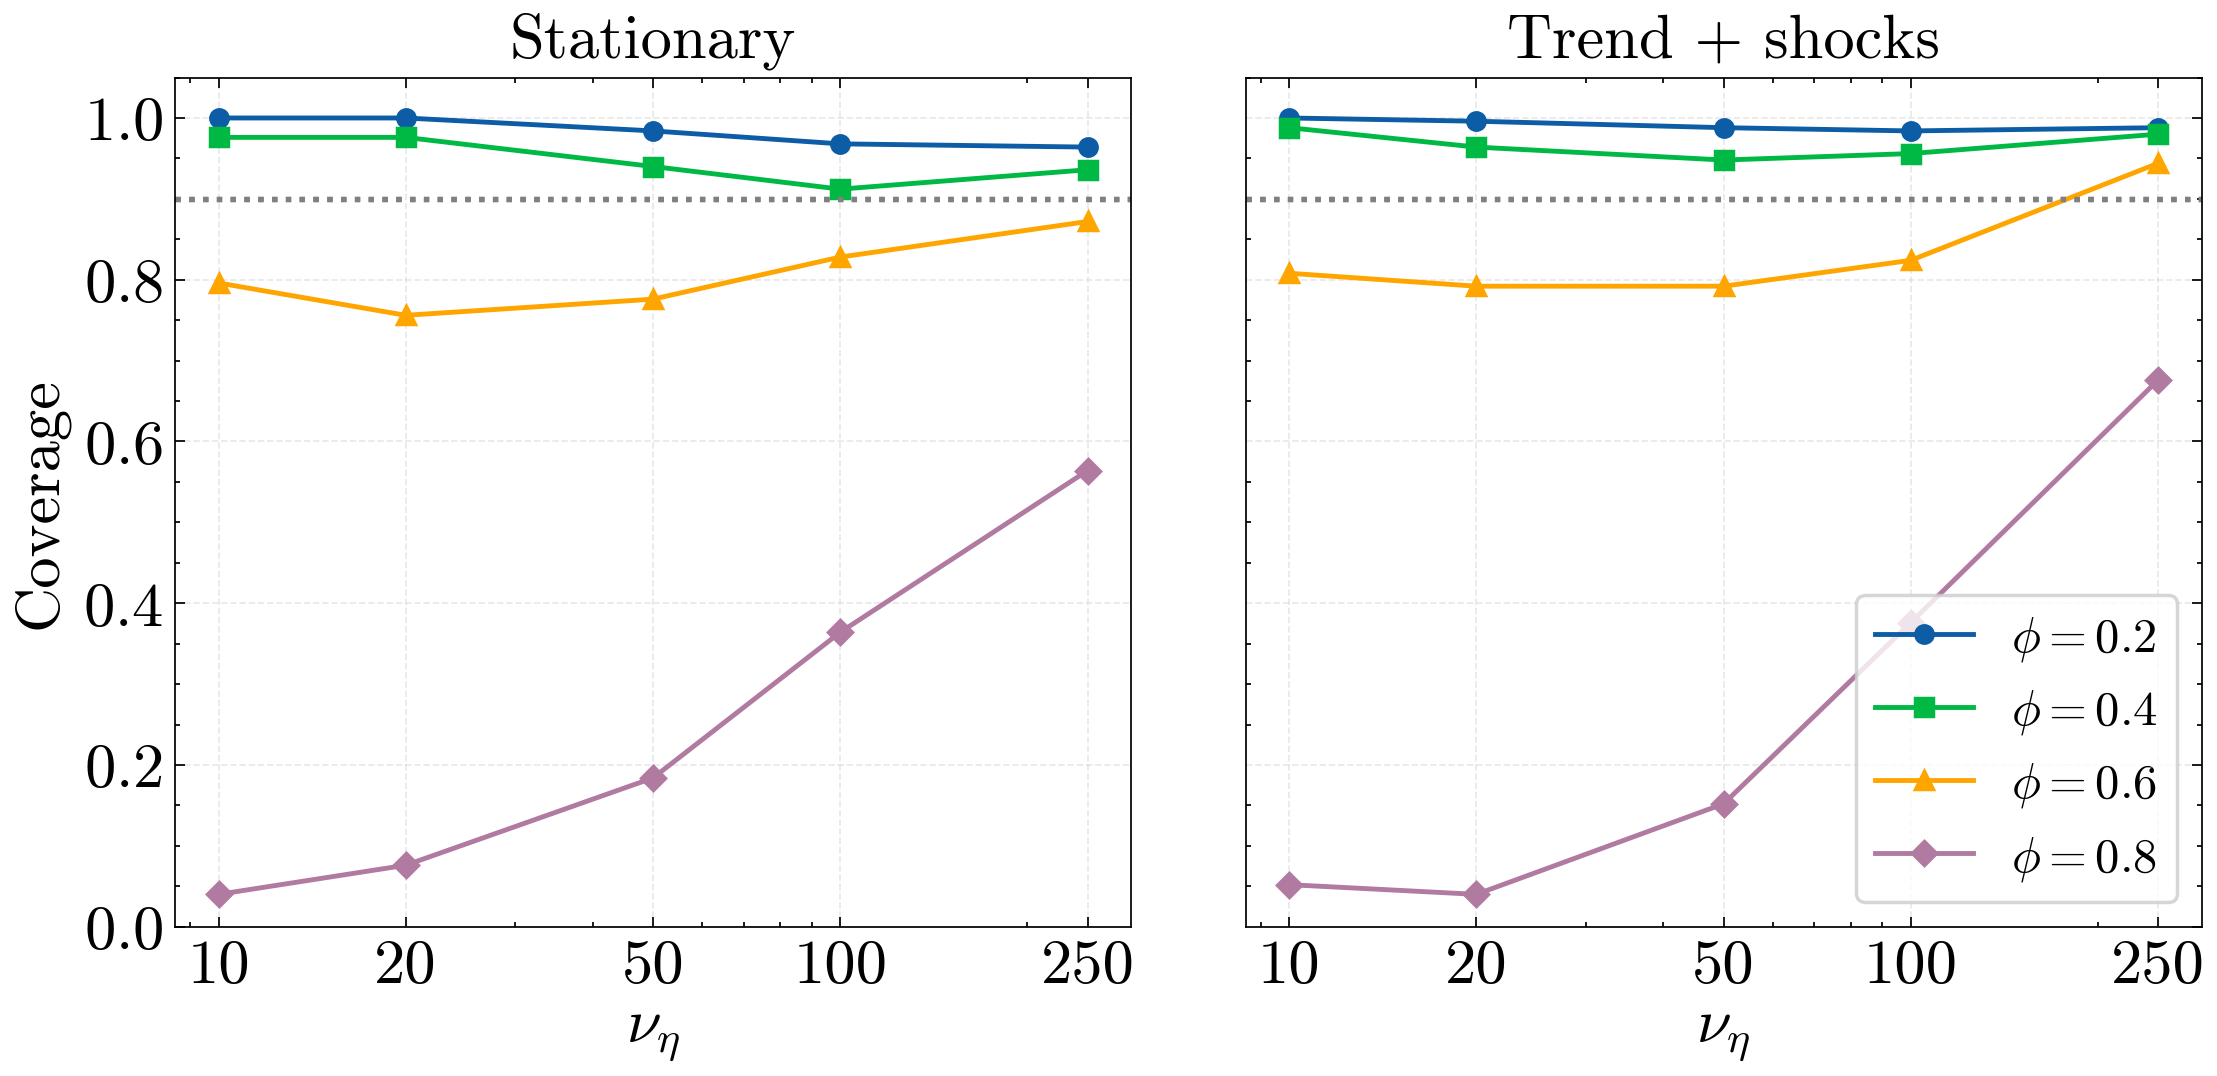

Saved to: /Users/toby/bootstrap/notebooks/figs/sweep_overlay_grid_ar1_ablation_long.pdf


In [4]:
root_long = base / "smooth-ewma_alpha-0p1" / "ablations_long"
panel_specs_long = {
    "Stationary": {"shock": "__shock-type-none_p-0_scale-1"},
    "Trend + shocks": {
        "shock": "__shock-type-permanent_p-0p005_scale-2",
        "tail": "__trend-0p001",
    },
}

paths_long = build_panels_paths_generic(
    root=root_long,
    phis={
        "0.2": r"$\phi=0.2$",
        "0.4": r"$\phi=0.4$",
        "0.6": r"$\phi=0.6$",
        "0.8": r"$\phi=0.8$",
    },
    methods=[("ARmmult", "student")],
    method_display={"ARmmult": ""},
    panel_specs=panel_specs_long,
    smooth="ewma",
    alpha="0.1",
    bi=500,
    vw=400,
    n=5000,
    nseries=250,
    B=200,
    nosmooth_var=True,
    sweep_prefix=False,
    include_method_token=True,
)

panels_long = load_panels_from_paths(paths_long, loader=UniformCoverageStudy.load_sweep)

outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)
save_path = outdir / "sweep_overlay_grid_ar1_ablation_long.pdf"

plotter = BootstrapPlotter(style="science", figsize=(9, 4), dpi=250)
fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels_long,
    order=["Stationary", "Trend + shocks"],
    layout=(1, 2),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=True,
    legend_in_panel=True,
    legend_panel_index=-1,
    legend_fontsize=14,
    tick_labelsize=18,
    axis_labelsize=18,
    title_size=18,
    marker_size=5,
    line_width=1.4,
    hspace=0.25,
    wspace=0.12,
    save_path=str(save_path),
    log_eta=True,
    color_by_group=True,
    group_from_label="identity",
    dashed_phi=None,
    ess=True,
)
print("Saved to:", save_path.resolve())